<center><h2>CRE III - Assignment 4 - Backmixing in tubular reactors </h2></center>
<center><h2> Solving Tubular Reactor Dynamics via Boundary and Initial Value Approaches </h2></center>
<center> Group :  Anastasia Schumacher, Hendrik Jarosch, Hjalte Paskowski  </center>


## 1. Introduction

Modeling non-ideal flow behavior in tubular reactors is a central challenge in chemical engineering, as it directly impacts the efficiency and reliability of industrial processes. Tubular reactors are widely used for gas-phase and liquid-phase reactions, and the ability to accurately simulate their performance is essential for process design, optimization, and scale-up. Real systems rarely behave ideally-dispersion, backmixing, and non-uniform flow profiles significantly affect reactor behavior. Thus, learning to apply numerical methods such as boundary value problems (BVPs), initial value problems (IVPs), and CSTR cascades enables chemical engineers to better predict and control reactor performance.

For example, a high dispersion coefficient might indicate poor plug flow behavior, which could require adjustments in reactor design. In cases where true plug flow is not feasible, using a cascade of CSTRs can be an effective strategy to approximate the desired flow characteristics. Additionally, comparing Bodenstein ($Bo$) numbers provides insight into how closely a system approximates ideal flow conditions, supporting better evaluation and optimization of reactor configurations.

This project focuses on modeling and analyzing a tubular reactor with a length of $10\,\mathrm{m}$ and a diameter of $32\,\mathrm{mm}$, which is fed by a gas stream from an upstream section of $150\,\mathrm{mm}$ diameter. The feed contains $100\,\mathrm{mol\,m}^{-3}$ of a reactant A, which is converted into product B through a chemical reaction. The volumetric flow rate is $1\,\mathrm{L\,s}^{-1}$.

The objective of this assignment is to implement and compare different reactor models and analyze the influence of dispersion and mixing within a tubular reactor. To achieve this, the project comprises three main components: first, solving the reactor behavior using a boundary value problem (BVP) and validating the results with an initial value problem (IVP); second, studying the impact of backmixing by systematically varying the dispersion coefficient and evaluating its effect through the Bodenstein number ($Bo$); and third, implementing a cascade of continuous stirred-tank reactors (CSTRs) and comparing its performance with the dispersion model.

By completing this assignment, we gain hands-on experience with essential reactor modeling tools that are directly applicable to real-world problems in chemical engineering fields such as petrochemical processing, pharmaceutical manufacturing, and catalytic reactor design.


## 2. Theoretical background

This chapter introduces the theoretical framework used to describe the behavior of tubular reactors under both ideal and non-ideal flow conditions. Section 2.1 presents the axial dispersion model, which captures deviations from ideal plug flow by incorporating molecular diffusion and backmixing. Section 2.2 outlines the Danckwerts boundary conditions required to formulate and solve the dispersion model as a boundary value problem. Section 2.3 describes the plug flow case as an initial value problem, focusing on the analytical solution for ideal conditions. Section 2.4 focuses on the experimental determination of residence time distributions. Finally, Section 2.5 defines the investigated reaction system and summarizes the physical and operational parameters used in the reactor model.

### 2.1 Axial dispersion in tubular reactors

In an ideal plug flow reactor (PFR), it is assumed that the flow profile is perfectly uniform and that no mixing occurs in the axial direction. Under this assumption, the component mass balance for species $i$ is expressed as:

\begin{align}
\frac{\partial c_i}{\partial t} &= -u \frac{\partial c_i}{\partial z} + \sum_j \nu_{i,j}  r_j \tag{1}
\end{align}

In steady-state operation, the time derivative on the left-hand side vanishes, resulting in a simplified one-dimensional convection-reaction equation. However, real reactors deviate from this ideal due to molecular diffusion and turbulent effects, which lead to axial dispersion. To account for this, an additional second-order spatial derivative is included, yielding the following steady-state model:

\begin{align}
u \frac{\mathrm{d}c_i}{\mathrm{d}z} &= \mathcal{D} \frac{\mathrm{d}^2 c_i}{\mathrm{d}z^2} + \sum_j \nu_{i,j}  r_j \tag{2}
\end{align}

Here, $\mathcal{D}$ is the axial dispersion coefficient, and the term $\mathcal{D} \frac{\mathrm{d}^2 c_i}{\mathrm{d}z^2}$ represents backmixing or diffusive transport along the reactor length. To assess the relative significance of dispersion, the dimensionless Bodenstein number $Bo$ is defined as:

\begin{align}
Bo &= \frac{u  L}{\mathcal{D}} \tag{3}
\end{align}

A high Bodenstein number corresponds to low axial dispersion and indicates behavior approaching ideal plug flow, while lower values reflect increasing deviation from the ideal case.

The extent of backmixing can be illustrated using the residence time distribution (RTD). A useful form for evaluating dispersion effects is the normalized RTD function $E(\Theta)$, which depends on the dimensionless time $\Theta$. For sufficiently high Bodenstein numbers ($Bo≥100$), the RTD can be approximated by a Gaussian distribution:

\begin{align}
E(\Theta) &= \frac{1}{\sqrt{4 \pi / Bo}}  \exp\left[ -\frac{(1 - \Theta)^2}{4 / Bo} \right] \tag{4}
\end{align}

This function characterizes how long fluid elements spend in the reactor, making it an effective tool for comparing different flow regimes.


### 2.2 Boundary conditions according to Danckwerts (BVP)

To solve the dispersion model formulated in equation (2), two boundary conditions must be specified. Unlike the ideal case, where inlet and outlet values are straightforward, real reactors require more careful treatment due to axial mixing.

At the reactor inlet ($z=0$), mixing causes the entering concentration to differ from the undisturbed feed concentration $c_{i,0}$. A balance of convective and dispersive fluxes at the entrance leads to the first boundary condition:

\begin{align}
u_0 A_0 c_{i0} &= u A c_i - A \mathcal{D} \frac{\mathrm{d} c_i}{\mathrm{d}z} \tag{5}
\end{align}

At the outlet ($z=L$), it is assumed that the concentration profile becomes flat, meaning no further gradient exists in the axial direction:

\begin{align}
\frac{\mathrm{d} c_i}{\mathrm{d}z} &= 0 \tag{6}
\end{align}

These conditions, known as Danckwerts boundary conditions, allow the formulation of a well-posed boundary value problem to describe concentration profiles in non-ideal tubular reactors.

### 2.3 Ideal plug flow as initial value problem (IVP)

In the absence of dispersion, the reactor behaves ideally, and the mass balance simplifies to a first-order differential equation under steady-state conditions:

\begin{align}
0 &= u \frac{\mathrm{d} c_i}{\mathrm{d}x} - \sum_j \nu_{i,j} , r_j \tag{7}
\end{align}

Only one initial condition is required to solve this equation: the concentration at the reactor inlet. For a first-order irreversible reaction A → B with rate law $r=k\,c_A$, the concentration profile along the reactor can be determined analytically:

\begin{align}
x = 0: \qquad c_A &= c_{A0}  \exp\left(-\frac{k x}{u}\right) \tag{8}
\end{align}

This expression provides a simple yet useful reference case for comparing the behavior of ideal and non-ideal reactors.

### 2.4 Experimental Determination of Residence Time Distribution [3]

To characterize the flow behavior in real tubular reactors, the residence time distribution (RTD) is often determined experimentally. The RTD provides insights into non-idealities such as axial dispersion, dead zones, or channeling, and is a key tool for evaluating deviations from ideal plug flow behavior.

Two standard methods for determining the RTD are described below:

***Impulse (Pulse) Input Experiment***

In an impulse experiment, a small quantity of an inert, non-reactive tracer is injected into the feed stream at time $t=0$. The tracer concentration at the reactor outlet is measured as a function of time $c(t)$. From this signal, the normalized residence time distribution function $E(t)$ is defined as:

\begin{align}
E(t) = \frac{c(t)}{\int_0^{\infty} c(t)dt} \tag{9}
\end{align}

The function $E(t)$ describes the probability density that a fluid element remains in the reactor for a time $t$. By introducing the dimensionless time $\Theta=t/\tau$, where $\tau$ is the mean residence time, the distribution becomes:

\begin{align}
E(\Theta) = \tau \cdot E(t) = \frac{V_R}{\dot{n}_{\text{t0}}} \cdot c(t) \tag{10}
\end{align}

This dimensionless form allows for the comparison of different reactor systems independently of scale.

***Step Input Experiment***

Alternatively, a step input experiment can be performed, in which the tracer concentration at the reactor inlet is suddenly changed from zero to a constant value $c_0$. The tracer concentration at the outlet $c(t)$ is then recorded over time. The resulting cumulative residence time distribution function $F(t)$ is defined as:

\begin{align}
F(t) &= \frac{c(t)}{c_0} = \frac{\dot{V}}{\dot{n}_{t0}} \cdot c(t) \tag{11}
\end{align}

In dimensionless form:

\begin{align}
F(\Theta) = F\left(\frac{t}{\tau}\right) \tag{12}
\end{align}

The relationship between the two RTD functions is given by:

\begin{align}
E(\Theta) = \frac{dF(\Theta)}{d\Theta} \tag{13}
\end{align}

with: 
$ \dot{V} $: volumetric flow rate  
$ V_R $: reactor volume  
$ \tau $: mean residence time  
$ \dot{n}_{A0} $: molar flow rate of component A at the inlet  
$ \dot{n}_{t0} $: molar flow rate of the injected tracer  
$ c(t) $: tracer concentration at the reactor outlet at time $ t $  
$ c_0 $: tracer concentration at the reactor inlet (typically for a step input)

This derivative reflects how rapidly fluid elements are exiting the reactor at a given time.

***Application and Significance:***

By comparing the measured RTD functions with theoretical models (e.g., ideal PFR, CSTR, dispersion model), the real flow behavior can be classified. For example, a very narrow peak in $E(\Theta)$ indicates plug-flow-like behavior, while a broad or multi-peak distribution signals strong backmixing or dead zones.

In addition, values such as the mean residence time, the variance, or the Bodenstein number range can be estimated from $E(\Theta)$, which in turn are crucial for modeling and reactor design.


### 2.5 Investigated reaction system

The system considered in this study is a single irreversible reaction:

\begin{align}
A \rightarrow B \qquad \text{with} \quad r &= k  c_A^n \tag{14}
\end{align}

In Chapter 3, the reaction is assumed to follow first-order kinetics ($n=1$). The process takes place in a tubular reactor, dimensions and operating parameters are summarized in Table 1.

**<center> Table 1: Reactor and stream specifications.**

<div align='center'>

|Parameter	| Value |
|-----------|-------|
|Reactor length L|	10 m |
|Reactor diameter d|	32 mm |
|Inlet diameter $d_0$ |​150 mm|
|Volumetric flow rate $V_0$|​	1 L/s|
|Feed concentration $c_A0$ |​	100 mol/m³ |

</div>



## 3. Methodology

Prior to the coding, some imports must be made. For this task, *numpy*, *matplotlib* and *scipy* is used.

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy

Also, some basic settings for the plotting are made.

In [2]:
# plotting settings
cmap = matplotlib.colormaps["viridis"]  # define used colormap
linestyles = ["-", "--", "-.", ":","-", "--", "-.", ":","-", "--", "-.", ":"]   # define list of linestyles

### 3.1 Concentration profiles
#### 3.1.1 Implementation of the dispersion model

To implement the dispersion model, the given parameters of the reactor and the reaction have to be defined.

In [3]:
L = 10                              # reactor length in m
D = 32e-3                           # reactor diameter in m
D_upstream = 150e-3                 # upstream tube diameter in m
V_dot = 0.001                       # volume flow rate in m³ s⁻¹
c_A_in = 100                        # inlet concentration of component A in mol m⁻³
c_in = np.array([c_A_in,0])         # array on inlet concentrations
stoich_coeff = np.array([-1,1])     # stoichiometric coefficients of the components
k = 1                               # rate constant in s⁻¹
n = 1                               # reaction order
Bo = 50                             # bodenstein number

Next, some geometrical calculations of the reactor are performed.

In [4]:
# geometric calculations
A = np.pi*D**2/4                # cross-sectional area of the reactor in m²
A_0 = np.pi*D_upstream**2/4     # cross-sectional area of the upstream tube in m²
V = A * L                       # volume of the reactor in m³
u = V_dot/A                     # velocity of the gas in the reactor in m s⁻¹
u_0 = V_dot/A_0                 # velocity of the gas in the upstream tube in m s⁻¹

The dispersion coefficient is calculated via equation (3):

In [5]:
Disp_coeff = u*L/Bo             # dispersion coefficient in s⁻¹

 The dispersion model as described in equation (2) and the corresponding boundary conditions shown in equation (5) and (6) is implemented as *dispersion_model* and *bc* function. The balance equation with its second order derivative is therefore rewritten into a system of differential equations shown in equation (15) and (16):

\begin{align}
\frac{\mathrm{d} c_i}{\mathrm{d} z}& = y \tag{15}\\
\frac{\mathrm{d}^2 c_i}{\mathrm{d} z^2} &= \frac{\mathrm{d} y}{\mathrm{d} z}  = \frac{1}{\mathcal{D}} \, \left( u \cdot y + \sum_j \nu_{i,j}  r_j \right) \tag{16}
\end{align}

In [6]:
def dispersion_model(z,S):
    """
    Computes the concentration gradients and second derivatives of concentration
    with respect to space for a dispersion model, based on input parameters and
    state values.

    :param z: Spatial variable, corresponding to the position in the reactor.
    :type z: np.ndarray
    :param S: State vector containing the concentrations and their respective
              first derivatives with respect to the spatial variable.
    :type S: np.ndarray
    :return: An array of the gradient of concentrations and their
             respective second derivatives with respect to the spatial variable.
    :rtype: np.ndarray
    """
    c = S[:2]                       # extract concentrations from input S
    dcdz = S[2:4]                   # extract concentration gradients
    d2cdz2 = np.zeros_like(dcdz)    # initialize an empty array of second derivatives
    d2cdz2[0] = 1/Disp_coeff*(u*dcdz[0] - stoich_coeff[0]*k*c[0]**n)    # balance equation of component 1 according to equation (16)
    d2cdz2[1] = 1/Disp_coeff*(u*dcdz[1] - stoich_coeff[1]*k*c[0]**n)    # balance equation of component 2 according to equation (16)
    return np.vstack((dcdz,d2cdz2))

def bc(ya, yb):
    """
    Computes boundary conditions of the BVP.

    :param ya: Array containing concentrations and concentration gradients at
        the starting boundary.
    :param yb: Array containing concentrations and concentration gradients at
        the final boundary.
    :return: A NumPy array representing the boundary conditions calculated
        for the initial and final points.
    :rtype: numpy.ndarray
    """
    c_z0 = ya[:2]       # extract concentrations of the left boundary
    c_zL = yb[:2]       # extract concentrations of the right boundary
    dcdz_z0 = ya[2:4]   # extract concentration gradients of the left boundary
    dcdz_zL = yb[2:4]   # extract concentration gradients of the right boundary
    bc_z0 = u*A*c_z0 - A*Disp_coeff*dcdz_z0 - u_0 * A_0 * c_in  # left boundary condition according to Danckwerts (equation (5))
    bc_zL = dcdz_zL     # right boundary condition according to Danckwerts (equation (6))
    return np.hstack((bc_z0,bc_zL))

In the next step, the initial mesh for solving the BVP is defined and the solve_bvp solver is called:

In [7]:
z = np.linspace(0,L,101)                                            # discretization of the rector length
y_init = np.zeros((4,z.size))                                       # generate initial mesh
sol = scipy.integrate.solve_bvp(dispersion_model,bc, z, y_init)     # solve the BVP

#### 3.1.2 Implementation of the plug flow reactor model

The balance equations of the PFR model shown in equation (7) are implemented as the *PFR* function:

In [8]:
def PFR(z, S):
    """
    Compute the concentration gradients in a Plug Flow Reactor (PFR).

    :param z: Position along the axial direction in the reactor
    :type z: float
    :param S: Array representing the concentration
    :type S: np.ndarray
    :return: Array of rate of change of the state variables at the given
        position
    :type return: np.ndarray
    """
    c = S[:2]                                   # extract concentrations
    dcdz = np.zeros_like(S)                     # initialize an empty array for the first derivatives
    dcdz[0] = 1/u *stoich_coeff[0]*k*c[0]**n    # balance equation of component 1 according to eq. (7)
    dcdz[1] = 1/u *stoich_coeff[1]*k*c[0]**n    # balance equation of component 2 according to eq. (7)
    return dcdz

For solving the ODE system, the initial conditions are set and the axial discretization is set. After that, the solve_ivp solver is called:

In [9]:
init_PFR = c_in             # define inlet conditions
z_span = np.array([0,L])    # set calculation boundaries
z = np.linspace(0,L,101)    # discretization of the reactor length
sol_PFR = scipy.integrate.solve_ivp(PFR,z_span, init_PFR, t_eval=z)     #solve the IVP

#### 3.1.3 Implementation of the CSTR cascade model

For the implementation of a CSTR cascade model, the Number of reactors and the residence time have to be defined first. In this case, the residence time of a single vessel was set to 1/Nth of the PFR residence time.

In [10]:
N = 11                  # number of CSTRs
tau_PFR = V/V_dot       # mean residence time of the PFR in s
tau = tau_PFR/N         # mean residence time of one vessel of the cascade in s

To solve the balance equation of a single CSTR for reaction orders other than one, a numerical solver is needed. In this case, the *root* solver from *scipy* is used. The CSTR balance of the k-th vessel of the cascade shown in equation (17) is implemented as *CSTR* function. The overall balance of the cascade is a combination of the balances of all vessels and is implemented as *CSTR_cascade* function.

\begin{align}
0 = c_{i,k-1} - c_{i,k} + \overline{\tau}_k \cdot \sum_{j} \nu_{i,j}\, k_j \,c_i^{n} \tag{17}\\
\end{align}

In [11]:
def CSTR(c, c_in):
    """
    Calculate the concentration change within a continuous stirred-tank reactor (CSTR).

    :param c: Current concentration of the reactants.
    :type c: np.ndarray
    :param c_in: Inflow concentration of the reactants.
    :type c_in: np.ndarray
    :return: The calculated concentration change in the reactor.
    :rtype: np.ndarray
    """
    res = c_in - c + tau*stoich_coeff*k*c[0]**n     # balance equation of a CSTR according to equation (17)
    return res

def CSTR_cascade(N,c_inlet):
    """
    Computes the concentration profiles in a cascade of Continuous Stirred Tank Reactors (CSTRs).

    :param N: Number of reactors in the cascade
    :type N: int
    :param c_inlet: Initial inlet concentration for the first reactor
    :type c_inlet: numpy.ndarray
    :return: Array containing inlet concentrations for all reactors in the cascade.
    :rtype: numpy.ndarray
    """
    c_out = np.zeros((N, 2))        # initialize empty result array
    c_in = np.zeros((N, 2))         # initialize empty result array
    c_in[0] = c_inlet               # set inlet of first reactor as inlet concentrations
    for i in range(N):              # iterate over all reactors of the cascade
        c_out[i] = scipy.optimize.root(CSTR, c_in[i], args=(c_in[i])).x[:2]     # solve system of equations via root
        if i < N-1:
            c_in[i+1] = c_out[i]    # set inlet concentration of the next reactor as the outlet concentration of the current reactor
    return c_in     # return inlet concentration to start array with cascade inlet concentrations

The cascade balance is solve by callin the *CSTR_cascade* function:

In [12]:
sol_Cascade = CSTR_cascade(N, c_in)     # solve the cascade balance
cascade_ns = np.linspace(0,N-1,N)       # linspace from 0 to 10

### 3.2 Residence time distributions
#### 3.2.1 Plug flow

As the assumption of a PFR is no back mixing, the residence time is not distributed but a single value which is the hydraulic residence time.
The E-function of a PFR is therefore a dirac-delta-function with its peak at the hydraulic residence time or $\Theta=1$ respectively. The F_function resembles a step function with a step from zero to one again at the hydraulic residence time or $\Theta=1$.

#### 3.2.2 Residence time distribution of a CSTR

To calculate the residence time distribution of a CSTR, the necessary reactor parameters have to be defined fist:

In [13]:
c_T_in = 1      # tracer inlet concentration in mol m⁻³
V_dot = 1e-3    # volumetric flow rate in m³ s⁻¹
V_R = 3         # reactor volume in m³

the mean residence time is calculated according to equation (19)

\begin{equation}
\overline{\tau} = \frac{V_\mathrm{R}}{\dot{V}} \tag{19}
\end{equation}

In [14]:
tau_mean = V_R/V_dot    # mean residence time in s

The residence time distribution of a CSTR can be gathered by solving the dynamic CSTR balance for no reaction with a step in function of the tracer concentration in the inlet as shown in equation (20). It is implemented as the *CSTR_balance_dynamic* function.

\begin{equation}
V_\mathrm{R} \frac{\mathrm{d} c_\mathrm{T}}{\mathrm{d} t} = \dot{V} \,(c_{\mathrm{T,in}}-c_{\mathrm{T}}) \tag{20}
\end{equation}

In [15]:
def CSTR_balance_dynamic(t, c_T):
    """
    Calculates the dynamic balance of a CSTR without a reaction.

    :param t: Time at which the dynamic balance is to be calculated.
    :type t: float
    :param S: Array representing the concentration
    :type c_T: np.ndarray
    :return: concentration gradient of the dynamic balance.
    :rtype: np.ndarray
    """
    dc_T_dt = V_dot/V_R * (c_T_in-c_T)  # dynamic balance accodring to equation (20)
    return dc_T_dt

Next, the range of the dimensionless residence time $\Theta$, as well as the initial tracer concentration is set. After that, the balance is solved using *solve_ivp*.

In [16]:
theta_span = np.array([0,3])                        # dimensionless timespan which is evaluated
c_T_a_0 = 0                                         # initial tracer composition
init = np.array([c_T_a_0])                          # initial value array
t_span = theta_span*tau_mean                        # timespan which is evaluated
t_eval = np.linspace(t_span[0], t_span[1], 1001)    # discretization of the timespan
sol_CSTR = scipy.integrate.solve_ivp(CSTR_balance_dynamic, t_span, init, t_eval=t_eval) # solving the IVP

After solving the balance, the F- and E-function is calculated via equation (21) and (22).

\begin{align}
F_\mathrm{CSTR}(\tau) = \frac{c_\mathrm{T,out}(\tau)}{c_\mathrm{T,in}} \tag{21}\\
E_\mathrm{CSTR}(\tau) = \frac{\mathrm{d} F_\mathrm{CSTR}(\tau)}{\mathrm{d} \tau}    \tag{22}\\
\end{align}

In [17]:
# calculate F(t) and E(t)
F_t_CSTR = sol_CSTR.y[0]/c_T_in         # F-function of the CSTR
dtau = np.gradient(sol_CSTR.t)          # differential timespan
E_t_CSTR = np.gradient(F_t_CSTR)/dtau   # E-function of the CSTR in s⁻¹

The F and E-function is transferred into a dimensionless form via equation (23), (24) and (25).

\begin{align}
\Theta_\mathrm{CSTR} &= \frac{t}{\overline{\tau}_{\mathrm{CSTR}}} \tag{23}\\
F_\mathrm{CSTR}(\Theta) &= F_\mathrm{CSTR}(\tau) \tag{24}\\
E_\mathrm{CSTR}(\Theta) &= E_\mathrm{CSTR}(\tau) \cdot \overline{\tau}_{\mathrm{CSTR}}  \tag{25}
\end{align}

In [18]:
# calculate F(Theta) and E(Theta)
theta_CSTR = sol_CSTR.t/tau_mean    # dimensionless timesteps
E_theta_CSTR = tau_mean * E_t_CSTR  # dimensionless E-function of the CSTR
F_theta_CSTR = F_t_CSTR             # dimensionless F_FUnction of the CSTR

#### 3.2.4 Residence time distribution of a CSTR cascade

For the calculation of the CSTR cascade residence time distribution, again the necessary reactor parameters have to be defined.

In [19]:
c_T_in = 1      # inlet tracer concentration in mol m⁻³
V_dot = 1e-3    # volumetric low rate in m³ s⁻¹
V_R = 1         # reactor volume of a single CSTR in m³
N_CSTR = 3      # number of CSTRs in the Cascade

Next, the mean residence time of a vessel and the whole cascade is calculated according to equations (26) and (27).

\begin{align}
\bar{\tau}_{\mathrm{vessel,}i} &= \frac{V_\mathrm{R_\mathnormal{i}}}{\dot{V}} \tag{26}\\
\bar{\tau}_{\mathrm{cascade}} &= \sum_{i=1}^{N} \bar{\tau}_{\mathrm{vessel,}i} \tag{27}
\end{align}

In [20]:
tau_mean_vessel = V_R/V_dot                 # mean residence time of a single vessel in s
tau_mean_cascade = N_CSTR*tau_mean_vessel   # mean residence time of the cascade

The dynamic balance of the CSTR cascade consists of the dynamic balances of all CSTRs. The balance of a sinlge vessel is shown in equation (28).

\begin{equation}
V_\mathrm{R_\mathnormal{i}} \frac{\mathrm{d} c_{\mathrm{T,}i}}{\mathrm{d} t} = \dot{V} \,(c_{\mathrm{T,}i-1}-c_{\mathrm{T,}i})  \tag{28}
\end{equation}

The balances of the sinlge CSTRs are implemented into a for-loop iterating over each CSTR inside the *CSTR_cascade_balance_dynamic* function:

In [21]:
def CSTR_cascade_balance_dynamic(t, c):
    """
    Calculates the dynamic balance of a CSTR cascade without a reaction.

    :param t: Time at which the dynamic balance is to be calculated in s.
    :type t: float
    :param c: concentration of the tracer in mol m⁻³.
    :type c: np.ndarray
    :return: concentration gradient of the tracer in each vessel.
    :rtype: np.ndarray
    """
    dcdt_i = np.zeros_like(c)                       # initialize empty results array
    for i in range(N_CSTR):                         # iterate over each vessel
        if i == 0:                                  # special case for first vessel: takes the inlet concentration of the cascade
            dcdt_i[i] = V_dot/V_R * (c_T_in-c[i])   # balance eqaution of the first vessel
        else:
            dcdt_i[i] = V_dot/V_R * (c[i-1]-c[i])   # balance equation of vessel i according to equation (28)
    return dcdt_i

Now, the cascade balance is solved using solve_ivp. Prior to that, the investigated dimensionless time range is defined.

In [22]:
theta_span = np.array([0,3])                        # dimensionless timespan which is evaluated
c_T_a_0 = 0                                         # initial tracer composition
init = np.ones(N_CSTR)*c_T_a_0                      # initial concentration array
t_span = theta_span*tau_mean_cascade                # timespan which is evaluated
t_eval = np.linspace(t_span[0], t_span[1], 1001)    # discretization of the timepsan
sol_Cascade = scipy.integrate.solve_ivp(CSTR_cascade_balance_dynamic, t_span, init, t_eval=t_eval, atol=1e-6, rtol=1e-6)    # solving the cascade IVP

With the solution of the balance, the F and E-function is calculated using the following equations:

\begin{align}
F_\mathrm{cascade}(\tau) = \frac{c_\mathrm{T,N,out}(\tau)}{c_\mathrm{T,1,in}} \tag{29}\\
E_\mathrm{cascade}(\tau) = \frac{\mathrm{d} F_\mathrm{cascade}(\tau)}{\mathrm{d} \tau}  \tag{30}
\end{align}

In [23]:
# calculate F(t) and E(t)
F_t_Cascade = sol_Cascade.y[-1]/c_T_in          # F-function of the cascade
dtau = np.gradient(sol_Cascade.t)               # differential timespan
E_t_Cascade = np.gradient(F_t_Cascade)/dtau     # E-function of the cascade in s⁻¹

The F and E-function is converted into a dimensionless form using the following equations:

\begin{align}
\Theta_\mathrm{cascade} &= \frac{t}{\bar{\tau}_{\mathrm{cascade}}} \tag{31}\\
F_\mathrm{cascade}(\Theta) &= F_\mathrm{cascade}(\tau) \tag{32}\\
E_\mathrm{cascade}(\Theta) &= E_\mathrm{cascade}(\tau) \cdot \bar{\tau}_{\mathrm{cascade}}  \tag{33}
\end{align}

In [24]:
# calculate F(Theta) and E(Theta)
theta_Cascade = sol_Cascade.t/tau_mean_cascade  # dimensionless timesteps
E_theta_Cascade = tau_mean_cascade*E_t_Cascade  # dimensionless E-function of the cascade
F_theta_Cascade = F_t_Cascade                   # dimensionless F-function of the cascade

#### 3.2.5 Dispersion model

To obtain the residence time of a tubular reactor with the dispersion model, again the necessary reactor parameters have to be defined.

In [25]:
L = 10              # reactor length in m
D = 32e-3           # reactor diameter in m
D_upstream = 150e-3 # upstream tube diameter in m
V_dot = 1e-3        # volumetric flow rate in m³ s⁻¹
c_T_in = 1          # inlet tracer concentration in mol m⁻³
Bo = 50             # bodenstein number
Disp_coeff = u*L/Bo # dispersion coefficient in s⁻¹

The same geometrical calculations as in 3.1.1 are performed afterward.

In [26]:
# geometric calculations
A = np.pi*D**2/4            # cross-sectional area of the reactor m²
A_0 = np.pi*D_upstream**2/4 # cross-sectional diameter of the upstream tube in m²
V = A * L                   # volume of the reactor in m³
u = V_dot/A                 # velocity of the gas in the reactor in m s⁻¹
u_0 = V_dot/A_0             # velocity of the gas in the upstream tube in m s⁻¹

The dynamic balance of a tubular reactor is a partial differential equation (PDE)as shown in equation (28), which cannot be solved using *solve_ivp* or *solve_bvp* directly.

\begin{equation}
\frac{\partial c_\mathrm{T}}{\partial t} = \mathcal{D} \frac{\partial^2 c_\mathrm{T}}{\partial z^2} - u \frac{\partial c_\mathrm{T}}{\partial z} \tag{34}
\end{equation}

Therefore, a discretization of the time is made by using the method of lines:

\begin{equation}
\frac{\partial c_\mathrm{T}}{\partial t} \approx \frac{c_\mathrm{T}(t_i)-c_\mathrm{T}(t_{i-1})}{\Delta t}   \tag{35}
\end{equation}

Now, the time discretization is inserted into equation (34) and reformulated into a system of ordinary differential equations to solve it with *solve_bvp*:

\begin{align}
\frac{\mathrm{d} c_\mathrm{T}}{\mathrm{d} z} &= y \tag{36}\\
\frac{\mathrm{d}^2 c_\mathrm{T}}{\mathrm{d} z^2} &= \frac{1}{\mathcal{D}} \cdot \left( \frac{c_\mathrm{T}(t_i)-c_\mathrm{T}(t_{i-1})}{\Delta t} + u \cdot y \right)   \tag{37}
\end{align}

The initial condition for the dynamic balance is given in equation (38):

\begin{equation}
c_\mathrm{T,init} = 0 \tag{38}
\end{equation}

The boundary conditions are stated in equation (39) and (40):

\begin{align}
\left.\frac{\partial c_\mathrm{T}}{\partial z}\right|_{z=0} &= (u\,A\,c_\mathrm{T}-u_0\,A_0\,c_\mathrm{T,in})\cdot\frac{1}{A\,\mathcal{D}}\tag{39}\\
\left.\frac{\partial c_\mathrm{T}}{\partial z}\right|_{z=L} &= 0    \tag{40}
\end{align}

The balance equations are implemented as *dispersion_model_tracer* function, with the corresponding boundary conditions as *bc_tracer* function.

In [27]:
theta_span = np.array([0,3])                            # dimensionless timespan which is investigated
tau_mean_disp = V/V_dot                                 # mean residence time of the reactor
t_span = theta_span*tau_mean_disp                       # timespan if the reactor

t_discrets = 101                                        # number of time discretization points
t_eval = np.linspace(t_span[0],t_span[1],t_discrets)    # discretization of the timespan
dt = (t_span[1]-t_span[0])/(t_discrets-1)               # differential timespan

c_T_initial = 0                                         # initial tracer concentration
def dispersion_model_tracer(z,S):
    """
    Calculates the dispersion model of a tubular reactor with a tracer without a reaction.

    :param z: reactor length in m
    :type z: np.ndarray
    :param S: state input containing the concentration and the concentration gradients for all timesteps
    :type S: np.ndarray
    :return: first and second order derivatives of the concentration in respect to the reactor length
    :rtype: np.ndarray
    """
    c_T = S[:t_discrets]                    # extract tracer concentrations
    dc_Tdz = S[t_discrets:2*t_discrets]     # extract concentration gradients
    d2c_dz2 = np.zeros_like(dc_Tdz)         # initialize empty results array for the second order derivatives
    for i in range(0, t_discrets):          # iterate over all timesteps
        if i == 0:                          # special case for i==0: use the initial tracer concentration
            d2c_dz2[i] = 1/Disp_coeff*((c_T[i]-np.ones_like(c_T[i])*c_T_initial)/dt+u*dc_Tdz[i])    # balance equation for first timestep
        else:
            d2c_dz2[i] = 1/Disp_coeff*((c_T[i]-c_T[i-1])/dt+u*dc_Tdz[i])    # balance equation for timestep i
    return np.vstack((dc_Tdz,d2c_dz2))

def bc_tracer(ya, yb):
    """
    boundary conditions for the dispersion model with tracer without a reaction.

    :param ya: concentrations and concentration gradients at the reactor inlet
    :type ya: np.ndarray
    :param yb: concentrations and concentration gradients at the reactor outlet
    :type yb: np.ndarray
    :return: array of boundary conditions
    :rtype: np.ndarray
    """
    c_z0 = ya[:t_discrets]                  # extract concentrations of the reactor inlet
    c_zL = yb[:t_discrets]                  # extract concentrations of the reactor outlet
    dcdz_z0 = ya[t_discrets:2*t_discrets]   # extract concentration gradients at the reactor inlet
    dcdz_zL = yb[t_discrets:2*t_discrets]   # extract concentration gradients at the reactor outlet
    bc_z0 = u*A*c_z0 - A*Disp_coeff*dcdz_z0 - u_0 * A_0 * c_T_in    # boundary conditions of the left side according to Danckwerts (equation (6))
    bc_zL = dcdz_zL                                                 # boundary conditions of the right side according to Danckwerts (equation (7))
    return np.hstack((bc_z0,bc_zL))

The system of ODEs is solved using *solve_bvp*:

In [28]:
z = np.linspace(0,L,101)                    # discretization of the reactor length
y_init = np.zeros((2*t_discrets,z.size))    # create initial mesh
sol_disp = scipy.integrate.solve_bvp(dispersion_model_tracer,bc_tracer, z, y_init) # solve the dispersion model BVP.

As already explained above, the F and E-function is calculated from the solution of the balance:

In [29]:
# calculate F(t) and E(t)
F_t_Disp = sol_disp.y[:t_discrets,-1]/c_T_in    # F-function of the tubular reactor
dtau= np.gradient(t_eval)                       # differential timespan
E_t_Disp = np.gradient(F_t_Disp)/dtau           # E-function of the tubular reactor in s⁻¹

Also, the functions are transferred into a dimensionless form again to make the results more comparable.

In [30]:
# calculate F(Theta) and E(Theta)
theta_Disp = t_eval/tau_mean_disp       # dimensionless timesteps
E_theta_Disp = tau_mean_disp*E_t_Disp   # dimensionless E-function of the tubular reactor
F_theta_Disp = F_t_Disp                 # F-function of the tubular reactor

### 3.3 Reactor performance

A measure for the reactor performance is the conversion $X$ of the reactants. The conversion is caclulated using equation (41).

\begin{equation}
X = 1- \frac{c_{i\mathrm{,out}}}{c_{i\mathrm{,in}}} \tag{41}
\end{equation}

Equation (41) is implemented as *conversion* function:

In [31]:
def conversion(c_out, c_in):
    """
    Calculates the conversion of a reactant in a reactor.

    :param c_out: Outlet concentration in mol m⁻³
    :type c_out: float

    :param c_in: Inlet concentration in mol m⁻³
    :type c_in: float

    :return: Conversion
    :rtype: float
    """
    X = 1 - c_out/c_in      # calculation of the conversion according to equation (41)
    return X

### 3.4 Model validation
To ensure the correctness of the implemented tubular reactor models, two validation steps are performed. First, the conservation of mass is verified by checking whether the sum of component concentrations remains $100\,\mathrm{mol\,L}^{-1}$ along the reactor length:

In [32]:
Bo = 1000                       # define high Bodenstein number
Disp_coeff = u*L/Bo             # dispersion coefficient in s⁻¹

y_init = np.zeros((4,z.size))                                         # generate initial mesh 
sol_val = scipy.integrate.solve_bvp(dispersion_model,bc, z, y_init)   # solve boundary value problem
val_sum_PFR = sol_PFR.y[0] +  sol_PFR.y[1]                            # sum of PFR concentrations
val_sum_dis = sol_val.y[0] + sol_val.y[1]                             # sum of dispersion model concentrations

if not np.allclose(val_sum_PFR, c_A_in) or not np.allclose(val_sum_dis, c_A_in):   # check if residual sum = inlet sum
    print('conservation of mass not given!')
else:
    print("Mass conserved!")

Mass conserved!


Second, the solution of the boundary value problem (BVP) for the dispersion model at a high Bodenstein number is compared to the initial value problem (IVP) of an ideal plug flow reactor. The high $Bo$ number of $1000$ is chosen because it represents a flow with negligible backmixing, approaching ideal plug flow conditions, which allows the two models to be meaningfully compared.  
Both steps are then plotted using the following code:

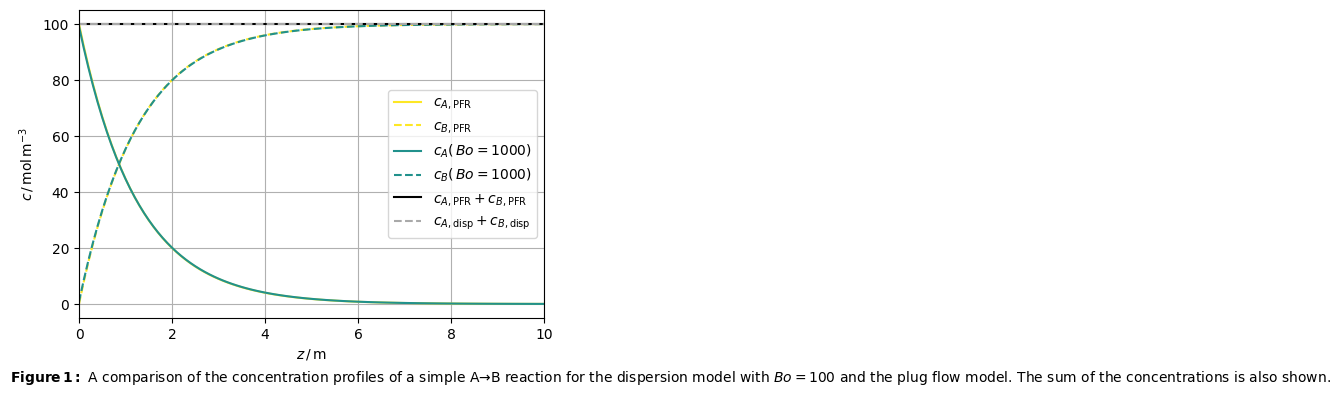

In [33]:
# get colormap and plot results of boundary value problem to compare with initial value problem
colors = cmap(np.linspace(0,1,3))
fig, ax = plt.subplots(1,1, figsize=(6,4))
ax.plot(sol_PFR.t, sol_PFR.y[0], color=colors[2], linestyle=linestyles[0], label=r"$c_{A,\mathrm{PFR}}$")
ax.plot(sol_PFR.t, sol_PFR.y[1], color=colors[2], linestyle=linestyles[1], label=r"$c_{B,\mathrm{PFR}}$")
ax.plot(sol_val.x, sol_val.y[0], color=colors[1], linestyle=linestyles[0], label=str(r"$c_{A}(\,Bo="+ str(Bo) +")$"))
ax.plot(sol_val.x, sol_val.y[1], color=colors[1], linestyle=linestyles[1], label=str(r"$c_{B}(\,Bo="+ str(Bo) +")$"))

ax.plot(val_sum_PFR, 'k', linestyle=linestyles[0], label=str(r"$c_{A,\mathrm{PFR}}+ c_{B,\mathrm{PFR}}$"))
ax.plot(val_sum_dis, 'darkgray', linestyle=linestyles[1], label=str(r"$c_{A,\mathrm{disp}} + c_{B,\mathrm{disp}}$"))
ax.grid()
ax.set_xlim(0,10)
ax.set_xlabel(r"$z\,/\,\mathrm{m}$")
ax.set_ylabel(r"$c\,/\,\mathrm{mol\,m}^{-3}$")
plt.legend(loc="right")
fig.text(
    0.01, -0.05,
    "$\\mathbf{Figure\\,1:}$ A comparison of the concentration profiles of a simple A→B reaction for the dispersion model with $Bo=100$ and the plug flow model. The sum of the concentrations is also shown.",
    ha='left',
    fontsize=10
)
plt.show()

Comparing the concentration profiles in **Figure 1** obtained from the boundary value problem of the dispersion model using high Bodenstein numbers and the initial value problem of the PFR, excellent agreement of both models is observed. This confirms that the implementation of both models is correct and that the BVP using $Bo=1000$ reproduces the expected ideal plug flow behavior with negligible backmixing.

## 4. Results and discussion

### 4.1 Comparison of different models
This study investigates how axial dispersion, characterized by the Bodenstein number ($Bo$), affects the concentration profiles of a first-order reaction A→B in a tubular reactor under steady-state conditions. The concentration changes of reactant A and product B are simulated and compared to the ideal plug flow behavior across varying degrees of dispersion.


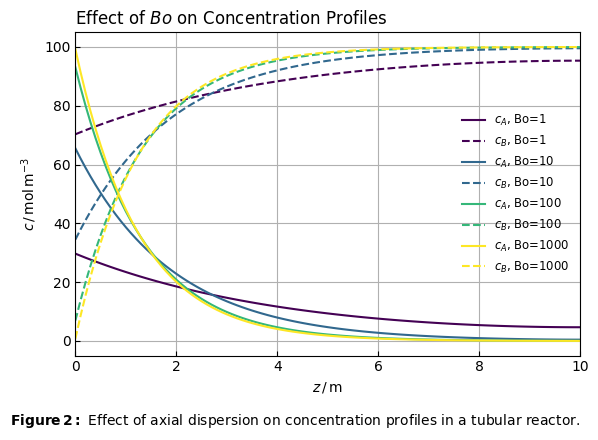

In [46]:
L = 10      # m
D = 32e-3      # m
D_upstream = 150e-3 # m
V_dot = 0.001       # m³ s⁻¹
c_A_in = 100    # mol m⁻³
c_in = np.array([c_A_in,0])
stoich_coeff = np.array([-1,1])
k = 1    # rate constant
n= 1   # reaction order

# geometric calculations
A = np.pi*D**2/4
A_0 = np.pi*D_upstream**2/4
V = A * L
u = V_dot/A
u_0 = V_dot/A_0

# Bodenstein numbers (dimensionless)
Bo = np.array([1, 10, 100, 1000])
# Corresponding axial dispersion coefficients [m²/s]
Dispersion_coeff = u * L / Bo
# Spatial domain along reactor length (z-axis)
z = np.linspace(0, L, 101)

sol={}
conversion_bo = []
for i in range(Bo.shape[0]):
    Disp_coeff = Dispersion_coeff[i]
    def dispersion_model(z,S):
        c = S[:2]
        dcdz = S[2:4]
        d2cdz2 = np.zeros_like(dcdz)
        d2cdz2[0] = 1/Disp_coeff*(u*dcdz[0] - stoich_coeff[0]*k*c[0]**n)
        d2cdz2[1] = 1/Disp_coeff*(u*dcdz[1] - stoich_coeff[1]*k*c[0]**n)
        return np.vstack((dcdz,d2cdz2))

    def bc(ya, yb):
        c_z0 = ya[:2]
        c_zL = yb[:2]
        dcdz_z0 = ya[2:4]
        dcdz_zL = yb[2:4]
        bc_z0 = u*A*c_z0 - A*Disp_coeff*dcdz_z0 - u_0 * A_0 * c_in
        bc_zL = dcdz_zL
        return np.hstack((bc_z0,bc_zL))

    y_init = np.zeros((4,z.size))

    sol[i] = scipy.integrate.solve_bvp(dispersion_model,bc, z, y_init)
    c_A_out = sol[i].y[0, -1]
    conversion = (c_A_in - c_A_out) / c_A_in
    conversion_bo.append(conversion)

def PFR(z, S):
    c = S[:2]
    dcdz = np.zeros_like(S)
    dcdz[0] = 1/u *stoich_coeff[0]*k*c[0]**n
    dcdz[1] = 1/u *stoich_coeff[1]*k*c[0]**n
    return dcdz 

init_PFR = np.array([c_A_in, 0])
z_span = np.linspace(0, L, 100)
sol_PFR = scipy.integrate.solve_ivp(PFR, [0, L], init_PFR, t_eval=z_span)
conversion_pfr = (c_A_in - sol_PFR.y[0, -1]) / c_A_in

fig, (ax1) = plt.subplots(1, 1, figsize=(6, 5), sharey=True)

# Left plot: all Bo variations
colors = cmap(np.linspace(0,1,4))
for i in range(len(Bo)):
    ax1.plot(sol[i].x, sol[i].y[0], color=colors[i], linestyle=linestyles[0], label=fr"$c_A$, Bo={Bo[i]}")
    ax1.plot(sol[i].x, sol[i].y[1], color=colors[i], linestyle=linestyles[1], label=fr"$c_B$, Bo={Bo[i]}")
ax1.set_title("Effect of $Bo$ on Concentration Profiles", loc="left")
ax1.set_xlabel(r"$z\,/\,\mathrm{m}$")
ax1.set_ylabel(r"$c\,/\,\mathrm{mol\,m}^{-3}$")
ax1.set_xlim(z[0], z[-1]) 
ax1.grid(True)
ax1.tick_params(direction = "in")  
ax1.legend(loc = 'best', fontsize="small", frameon = False)

# Final layout and figure label
fig.text(
    0.01, 0.14,
    "$\\mathbf{Figure\\,2:}$ Effect of axial dispersion on concentration profiles in a tubular reactor.",
    ha='left',
    fontsize=10
)
plt.tight_layout(rect=[0, 0.17, 1, 1])
plt.show()

To investigate the influence of axial dispersion on the conversion of species A in a first-order reaction (A → B), the reactor model was solved for various Bodenstein numbers $Bo=1,10,100,1000$. The resulting concentration profiles for species A and B are shown in **Figure 2**. The left subplot illustrates the evolution of concentration profiles under increasing Bo values, while the right subplot compares the high-Bo case ($Bo = 1000$) to the ideal plug flow reactor (PFR).

**Influence of Axial Dispersion:**

**$Bo = 1$ (Strong Dispersion):**

Significant backmixing causes a gradual and extended conversion of A along the entire reactor length. The concentration of A decreases slowly, and the formation of product B is distributed across the reactor. Total conversion is reduced, and the profile deviates strongly from ideal plug flow behavior.

**$Bo = 10$ and $Bo = 100$ (Moderate Dispersion):**

With decreasing dispersion, concentration profiles become steeper. The conversion of A begins to localize toward the inlet region. At $Bo = 100$, the concentration of A drops rapidly in the first part of the reactor, and the system begins to closely resemble plug flow. The efficiency of conversion increases significantly.

**$Bo = 1000$ (Minimal Dispersion):**

At this high $Bo$ value, dispersion effects are nearly absent. The reaction occurs almost entirely at the reactor inlet. The concentration of A decreases sharply, and the resulting profile is nearly indistinguishable from that of an ideal PFR. Product B is formed rapidly and remains constant along the remaining reactor length.

**Conclusion**

The simulation confirms the critical influence of the Bodenstein number on the performance of tubular reactors. At low $Bo$ values, significant axial dispersion occurs, disrupting ideal plug flow behavior and leading to reduced overall conversion an effect that is particularly detrimental for fast or sensitive reactions. In contrast, high $Bo$ numbers ($≥1000$) effectively suppress dispersion, resulting in sharp and localized reaction zones near the reactor inlet. This enhances conversion efficiency and closely approximates the behavior of an ideal plug flow reactor. The transition from dispersed to near-ideal flow becomes especially evident in the range between $Bo = 100$ and $Bo = 1000$.

From a design perspective, ensuring sufficiently high Bo values is essential, especially in processes where high yield, narrow residence time distributions, or reaction localization are critical. Even for simple kinetics, such as first-order reactions, axial dispersion can significantly affect reactor performance and should be carefully accounted for during modeling and scale-up.

#### Cascade Modell vs. ideal PFR

In this simulation, the performance of CSTR cascades with different numbers of tanks ($N = 10, 20, 30, 50$) is evaluated and compared to the ideal plug flow reactor (PFR). The goal is to investigate how increasing the number of ideal stirred tanks in series approaches the behavior of a PFR and how this influences the concentration profiles of reactant A and product B.

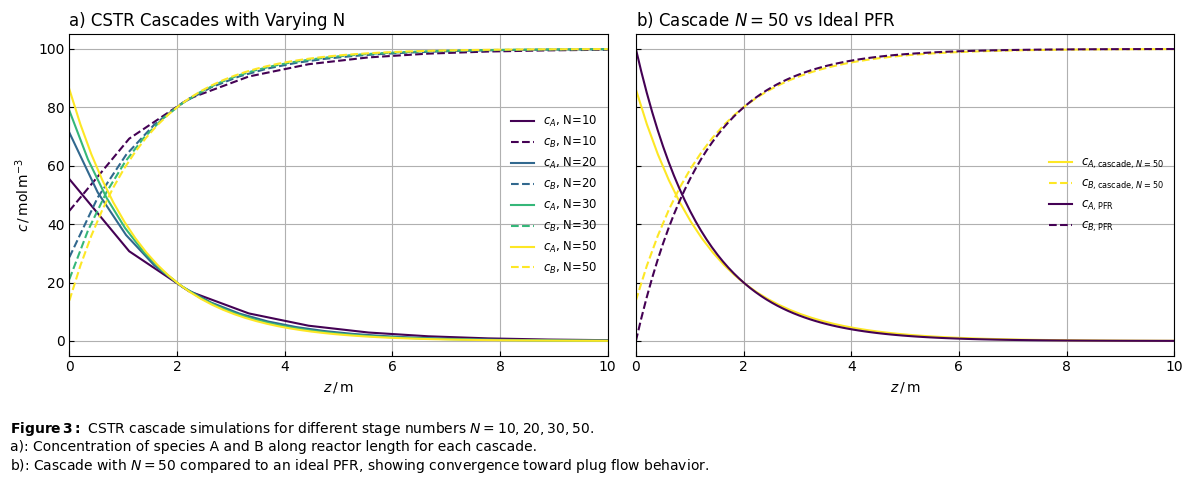

In [39]:
tau_PFR = V / V_dot  # Space time of ideal PFR

z_span = np.linspace(0, L, 100)
sol_PFR = scipy.integrate.solve_ivp(PFR, [0, L], c_in, t_eval=z_span)

def CSTR(c, c_in, tau):
    return c_in - c + tau * stoich_coeff * k * c[0]**n

def CSTR_cascade(N, c_inlet):
    tau = tau_PFR / N
    c_out = np.zeros((N, 2))
    c_in = np.zeros((N, 2))
    c_in[0] = c_inlet
    for i in range(N):
        sol = scipy.optimize.root(CSTR, c_in[i], args=(c_in[i], tau))
        c_out[i] = sol.x
        if i < N - 1:
            c_in[i+1] = c_out[i] #outlet stream CSTR(i) is inlet stream CSTR(i+1)
    return c_out


cascade_conversions = {}
# Simulation for Different Cascade Sizes
Ns = [10, 20, 30, 50]
cascades = {}
for N in Ns:
    cascades[N] = CSTR_cascade(N, c_in)
    sol_Cascade = CSTR_cascade(N, c_in)
    conversion_cascade = (c_A_in - sol_Cascade[-1, 0]) / c_A_in
    cascade_conversions[N] = conversion_cascade



# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Left: Different cascade sizes
colors = cmap(np.linspace(0,1,4))
for i, N in enumerate(Ns):
    z_cascade = np.linspace(0, L, N)
    axes[0].plot(z_cascade, cascades[N][:,0], color=colors[i], linestyle=linestyles[0], label=fr"$c_A$, N={N}")
    axes[0].plot(z_cascade, cascades[N][:,1], color=colors[i], linestyle=linestyles[1], label=fr"$c_B$, N={N}")
axes[0].set_title("a) CSTR Cascades with Varying N", loc="left")
axes[0].set_xlabel(r"$z\,/\,\mathrm{m}$")
axes[0].set_ylabel(r"$c\,/\,\mathrm{mol\,m}^{-3}$")
axes[0].set_xlim(z[0], z[-1]) 
axes[0].grid(True)
axes[0].tick_params(direction = "in")  
axes[0].legend(loc = 'best', fontsize="small", frameon = False)

# Right: Comparison with ideal PFR
colors = cmap(np.linspace(0,1,2))
z_N = np.linspace(0, L, 50)
axes[1].plot(z_N, cascades[50][:,0], color=colors[1], linestyle=linestyles[0], label=r"$c_{A,\mathrm{cascade},\,N=50}$")
axes[1].plot(z_N, cascades[50][:,1], color=colors[1], linestyle=linestyles[1], label=r"$c_{B,\mathrm{cascade},\,N=50}$")
axes[1].plot(sol_PFR.t, sol_PFR.y[0], color=colors[0], linestyle=linestyles[0], label=r"$c_{A,\mathrm{PFR}}$")
axes[1].plot(sol_PFR.t, sol_PFR.y[1], color=colors[0], linestyle=linestyles[1], label=r"$c_{B,\mathrm{PFR}}$")
axes[1].set_title("b) Cascade $N=50$ vs Ideal PFR", loc ="left")
axes[1].set_xlabel(r"$z\,/\,\mathrm{m}$")
axes[1].set_xlim(z[0], z[-1]) 
axes[1].grid(True)
axes[1].tick_params(direction = "in")  
axes[1].legend(loc = 'best', fontsize="small", frameon = False)

fig.text(
    0.01, 0.05,
    "$\\mathbf{Figure\\,3:}$ CSTR cascade simulations for different stage numbers $N=10,20,30,50$. \n"
    "a): Concentration of species A and B along reactor length for each cascade.\n"
    "b): Cascade with $N=50$ compared to an ideal PFR, showing convergence toward plug flow behavior.",
    ha='left',
    fontsize=10
)
plt.tight_layout(rect=[0, 0.17, 1, 1])
plt.show()

The simulation results presented in **Figure 3** demonstrate how the number of tanks in a CSTR cascade affects the conversion and concentration profiles of reactant A and product B, and how closely the system approaches the ideal plug flow reactor (PFR) behavior.

**$N = 10$ (Few Tanks):**
The concentration of reactant A decreases only slightly across the cascade. Due to strong backmixing in each tank, the concentration gradient is weak, and the reaction progresses slowly. As a result, the overall conversion is low, and the concentration of product B remains far below its maximum potential.

**$N = 20$ and $N = 30$ (Moderate Number of Tanks):**
With more tanks, the flow becomes more stratified and the concentration of A drops more significantly in the earlier part of the cascade. Product B is formed more efficiently, and the system starts to exhibit characteristics closer to a plug flow behavior. The differences compared to the ideal PFR become smaller, especially at $N = 30$.

**$N = 50$ (Many Tanks):**
At this level, the system approximates the ideal PFR very well. The concentration of A rapidly declines at the front of the cascade, and product B builds up correspondingly. The profiles for both species align closely with those from the ideal PFR solution, confirming that backmixing is minimal and that the reactor behaves almost like a continuous plug flow.

As the number of stirred tanks (CSTRs) in the cascade increases, the flow structure improves, which leads to a higher conversion of reactant A. At the same time, the extent of backmixing decreases, reducing its detrimental effect on the reaction yield. The concentration profiles become increasingly steeper and more localized as the number of tanks increases, which is particularly evident at high $N$. For the present system with a first-order reaction, a good approximation behavior to the ideal plug flow can be determined from about $N ≥ 30$. These results highlight the trade-off between system complexity and performance. For applications where achieving near plug-flow behavior is important but true tubular reactors are impractical, a sufficiently long CSTR cascade is a viable alternative.

#### Conversion Results for All Reactor Models

In this section, the conversion results for all implemented reactor models are presented and compared. These include the dispersion model at four different Bodenstein numbers ($Bo$), the ideal plug flow reactor (PFR), and CSTR cascade models with varying numbers of tanks ($N = 10, 20, 30, 50$). The objective is to quantify how closely each model approximates the ideal plug flow behavior and to evaluate the influence of axial dispersion and backmixing on reactor performance.

The results are summarized in Table 2: 

**<center> Table 2: Conversion results for all reactor models.**

<div align='center'>

| Model Description              | $X\,/\,\%$ |
|--------------------------------|-------|
| $Bo = 1$ (Dispersion Model)    | 95.32 |
| $Bo = 10$ (Dispersion Model)   | 99.54 |
| $Bo = 100$ (Dispersion Model)  | 99.94 |
| $Bo = 1000$ (Dispersion Model) | 99.96 |
| Ideal Plug Flow (PFR)          | 99.96 |
| CSTR Cascade ($N = 10$)        | 99.72 |
| CSTR Cascade ($N = 20$)        | 99.88 |
| CSTR Cascade ($N = 30$)        | 99.91 |
| CSTR Cascade ($N = 50$)        | 99.94 |

</div> 



The conversion values show that all systems achieve relatively high conversion due to the fast reaction kinetics used. However, subtle differences between the models highlight the impact of flow behavior on reactor efficiency.

In the dispersion model, increasing the Bodenstein number significantly improves conversion: from $0.9532$ at $Bo = 1$ to $0.9996$ at $Bo = 1000$. This reflects the reduction in backmixing with increasing Bo. At $Bo = 1000$, the conversion is essentially identical to that of the ideal plug flow reactor (PFR), which also yields $0.9996$, confirming that high-Bo systems effectively replicate plug flow conditions.

The CSTR cascade model also shows a clear trend: at $N = 10$, conversion reaches $0.9972$, already quite close to the plug flow result. With more tanks, the conversion continues to increase, reaching $0.9994$ at $N = 50$, nearly matching the PFR. These results demonstrate that a sufficiently long cascade can effectively mimic plug flow without relying on high axial velocities or long tubes.

**Important Note on Model Comparability**

It is important to note that, despite the numerical similarity in conversion values, the plug flow reactor (PFR) and the CSTR cascade differ fundamentally in their spatial structure. The PFR and the dispersion model describe concentration changes along a physical reactor length $z$, whereas the CSTR cascade consists of a series of well-mixed volumes and has no true spatial dimension in the axial direction.

Therefore, comparing the models purely based on concentration profiles along $z$ can be misleading. A more appropriate and physically consistent approach for comparing such systems is through residence time distribution (RTD) functions, which describe how long fluid elements spend in the reactor. RTD analysis allows for a fair and rigorous evaluation of how close a given system behaves to ideal flow models, such as plug flow or complete mixing, regardless of geometry.

### 4.2 Variation of the reaction order

In this Chapter, the concentration profiles of a reaction A→B, already described in Chapter 2.5., are simulated in a tubular reactor, taking axial dispersion into account. The reaction is studied using generalized reaction kinetics, with the reaction order n being specifically varied. In addition, the influence of the Bodenstein number ($Bo$), which describes the extent of backmixing along the reactor, is analyzed.

The aim of the simulation is to investigate the combined effects of reaction order and dispersion on the conversion and distribution of substances A (reactant) and B (product) in the reactor.

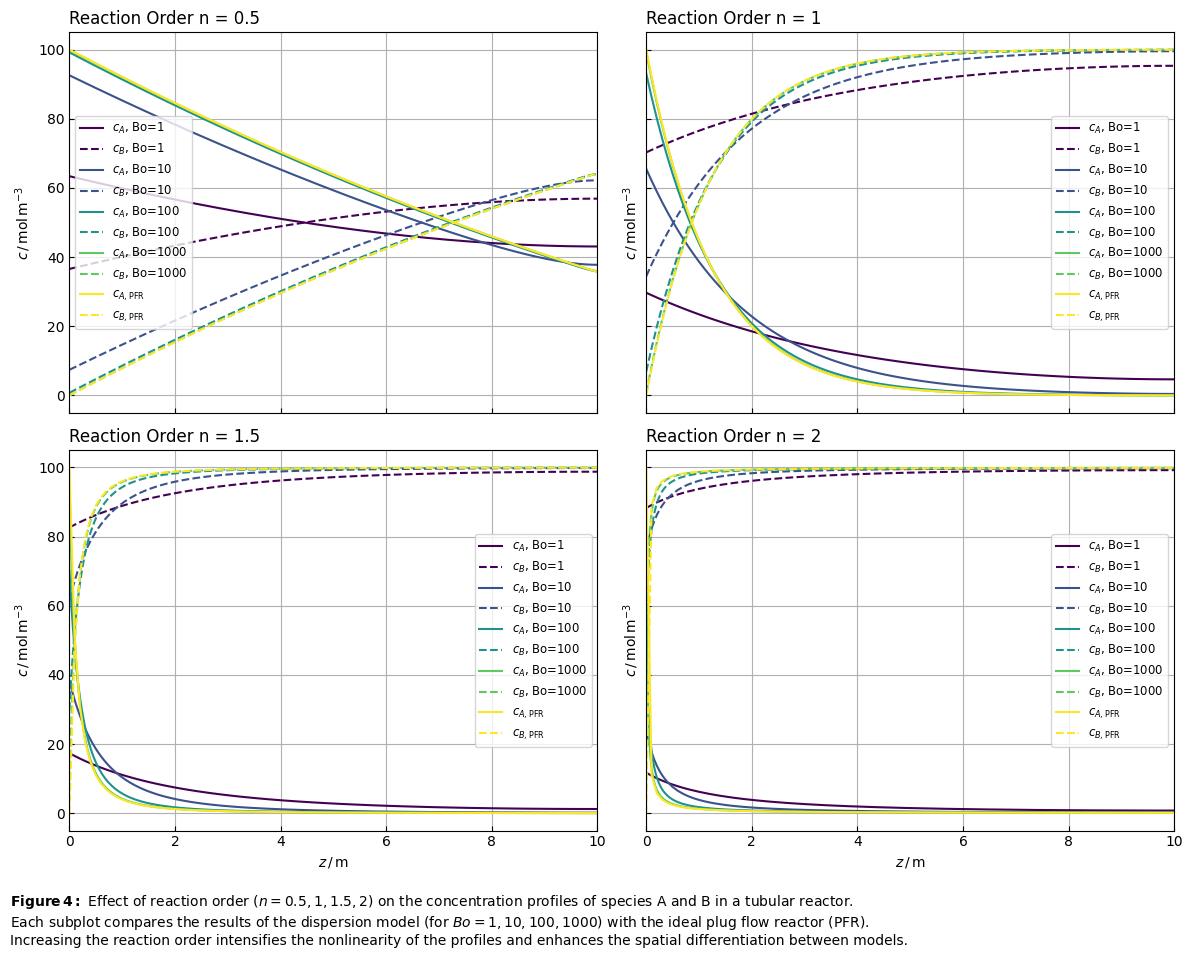

In [40]:
# Reaction orders to simulate
n_values = [0.5, 1, 1.5, 2]

# Dictionaries to store simulation results
results = {}       # For dispersion model solutions
pfr_results = {}   # For ideal PFR solutions

# Outer loop over reaction orders
for n in n_values:
    sol = {}  # Temporary dictionary to store results for current reaction order
    
    # Inner loop over Bo values (each represents a different dispersion intensity)
    for i in range(Bo.shape[0]):
        Disp_coeff = Dispersion_coeff[i]

        # Define the dispersion model ODE system as a second-order BVP
        def dispersion_model(z, S):
            c = S[:2]           # Concentrations of A and B
            dcdz = S[2:4]       # First derivatives (dc/dz)
            d2cdz2 = np.zeros_like(dcdz)  # Second derivatives (d²c/dz²)
            
            # Reaction rate using power-law kinetics
            rate = k * np.maximum(c[0], 1e-8)**n  # Use max to avoid negative or zero in fractional powers

            # Discretized axial dispersion model equations
            d2cdz2[0] = 1 / Disp_coeff * (u * dcdz[0] - stoich_coeff[0] * rate)
            d2cdz2[1] = 1 / Disp_coeff * (u * dcdz[1] - stoich_coeff[1] * rate)
            
            return np.vstack((dcdz, d2cdz2))  # Return 1st and 2nd derivatives

        # Boundary conditions according to Danckwerts (inlet + outlet)
        def bc(ya, yb):
            c_z0 = ya[:2]      # Concentrations at z = 0
            c_zL = yb[:2]      # Concentrations at z = L
            dcdz_z0 = ya[2:4]  # Derivatives at z = 0
            dcdz_zL = yb[2:4]  # Derivatives at z = L

            # Inlet condition (Danckwerts equation)
            bc_z0 = u * A * c_z0 - A * Disp_coeff * dcdz_z0 - u_0 * A_0 * c_in

            # Outlet condition (zero gradient)
            bc_zL = dcdz_zL

            return np.hstack((bc_z0, bc_zL))

        # Initial guess for the solver (4 rows: c_A, c_B, dc_A/dz, dc_B/dz)
        y_init = np.zeros((4, z.size))

        # Solve boundary value problem using SciPy
        sol[i] = scipy.integrate.solve_bvp(dispersion_model, bc, z, y_init)

    # Store results for this reaction order
    results[n] = sol

 
    # Solve Ideal Plug Flow Reactor (PFR) as IVP
    # Define the ODE system for ideal PFR (no dispersion, only convection + reaction)
    def PFR(z, S):
        c = S[:2]
        rate = k * np.maximum(c[0], 1e-8)**n
        dcdz = np.zeros_like(S)
        dcdz[0] = stoich_coeff[0] * rate / u
        dcdz[1] = stoich_coeff[1] * rate / u
        return dcdz

    # Initial condition: feed at z = 0
    init_PFR = np.array([c_A_in, 0])
    z_span = np.array([0, L])

    # Solve IVP using solve_ivp
    sol_PFR = scipy.integrate.solve_ivp(PFR, z_span, init_PFR, t_eval=z)

    # Store PFR result
    pfr_results[n] = sol_PFR


# Plotting Results
colors = cmap(np.linspace(0,1,5))
# Create a 2x2 subplot grid for the four reaction orders
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)

# Flatten axes array for easier indexing
axes = axes.flatten()

# Loop through each reaction order and plot
for idx, n in enumerate(n_values):
    ax = axes[idx]
    sol_n = results[n]
    
    for i in range(Bo.shape[0]):
        ax.plot(sol_n[i].x, sol_n[i].y[0], color=colors[i], linestyle=linestyles[0],
                label=fr"$c_A$, Bo={Bo[i]}")
        ax.plot(sol_n[i].x, sol_n[i].y[1], color=colors[i], linestyle=linestyles[1],
                label=fr"$c_B$, Bo={Bo[i]}")

    ax.plot(pfr_results[n].t, pfr_results[n].y[0], color=colors[-1], linestyle=linestyles[0], label=r"$c_{A,\mathrm{PFR}}$")
    ax.plot(pfr_results[n].t, pfr_results[n].y[1], color=colors[-1], linestyle=linestyles[1], label=r"$c_{B,\mathrm{PFR}}$")

    ax.set_title(f"Reaction Order n = {n}", loc="left")
    ax.set_ylabel(r"$c\,/\,\mathrm{mol\,m}^{-3}$")
    ax.grid(True)
    ax.set_xlim(z[0], z[-1])
    ax.tick_params(direction="in")
    ax.legend(loc='best', fontsize="small")

# Shared x-axis label
for ax in axes[2:]:
    ax.set_xlabel(r"$z\,/\,\mathrm{m}$")

fig.text(
    0.01, 0.05,
    "$\\mathbf{Figure\\,4:}$ Effect of reaction order ($n = 0.5, 1, 1.5, 2$) on the concentration profiles of species A and B in a tubular reactor.\n"
      "Each subplot compares the results of the dispersion model (for $Bo = 1, 10, 100, 1000$) with the ideal plug flow reactor (PFR).\n"
      "Increasing the reaction order intensifies the nonlinearity of the profiles and enhances the spatial differentiation between models.",
    ha='left',
    fontsize=10
)

plt.tight_layout(rect=[0, 0.11, 1, 1])
plt.show()

To investigate the influence of reaction kinetics on the concentration profiles in a tubular reactor, four different reaction orders were simulated: $n=0.5, 1, 1.5$ and $2$. For each of these cases, four different Bodenstein numbers ($Bo=1, 10, 100, 1000$) were considered to assess the effects of axial dispersion on reactor performance. The results clearly illustrate how both the reaction order and the extent of backmixing shape the concentration profiles of the reactant A and product B along the reactor length.

**Reaction Order $n=0.5$**

In this case of fractional reaction order, the reaction rate is only weakly dependent on the concentration of A. As a result, the reaction proceeds at a significant rate even at low concentrations. The simulated concentration profiles show a relatively uniform decrease in $c_A$ along the reactor, with minimal sensitivity to the Bodenstein number. Even under strong backmixing conditions ($Bo = 1$), the conversion remains relatively high. Product formation is continuous throughout the reactor, and the difference from the ideal plug-flow behavior is minor.

**Reaction Order $n=1$**

As previously described, a first-order reaction exhibits exponential decay in the reactant concentration. With increasing axial dispersion (lower $Bo$), the conversion decreases, and the concentration profile of A flattens noticeably. For high $Bo$ values, the concentration profile becomes steeper and closely approximates the ideal PFR solution. At $Bo = 1000$, nearly the entire conversion takes place at the reactor inlet, and the system behaves almost identically to an ideal plug-flow reactor.

**Reaction Order $n=1.5$**

This intermediate-order reaction shows a mixed behavior. The conversion becomes more localized toward the reactor inlet compared to the first-order case, but not as sharply as in the second-order case. Backmixing already causes significant inhibition of conversion. At $Bo = 1$, a considerable portion of A remains unreacted at the outlet. Only at higher Bo numbers does the reaction proceed efficiently. Compared to $n=1$, this system is more sensitive to the effects of axial dispersion.

**Reaction Order $n=2$**

For the second-order reaction, the reaction rate is strongly dependent on concentration. As a result, nearly all the conversion occurs at the reactor entrance-especially at high $Bo$ values. Once the concentration of A begins to drop, the reaction rate decreases drastically. In this case, backmixing has a very detrimental effect: at $Bo = 1$, the dilution of A due to upstream dispersion substantially reduces the reaction rate, and conversion is minimal. Only at $Bo = 1000$ does the system approach ideal plug-flow behavior, with a very steep concentration gradient of A near the inlet.

**Overall Assessment**

The simulation confirms that both the reaction order and the degree of axial dispersion, as represented by the Bodenstein number ($Bo$), are critical factors influencing the performance of a tubular reactor. The behavior of the system changes notably depending on these parameters.

For low reaction orders (e.g., $n=0.5$), the reactor remains relatively robust even under conditions of strong backmixing. The reaction rate stays sufficiently high throughout the reactor length, allowing for significant conversion despite the presence of axial dispersion. These systems are therefore more tolerant to non-ideal flow conditions.

In contrast, high-order reactions (e.g., $n=2$) are much more sensitive to concentration gradients. In such cases, achieving high conversion requires a high Bo number to suppress backmixing and maintain steep concentration profiles. At lower $Bo$ values, the axial dispersion near the reactor inlet leads to a significant dilution of reactant A, which causes the reaction rate to collapse due to the power-law dependence on concentration.

As a result, the deviation from ideal plug flow behavior becomes more pronounced with decreasing $Bo$, especially in systems governed by higher reaction orders. In these scenarios, the combined effects of dispersion and nonlinear kinetics lead to considerable performance losses, highlighting the need for careful reactor design when dealing with sensitive or fast reactions.

**Implications for reactor design:**
A thorough understanding of the underlying reaction kinetics is essential for selecting appropriate reactor geometries and operating conditions. For reactions of high order, it is recommended to operate under low-dispersion conditions ($Bo \gg 100$) to avoid conversion losses due to backmixing. Conversely, for reactions of low order, some degree of axial dispersion can be tolerated without a substantial loss in reactor performance.

### 4.3 Variation of $Bo$
In this section, the influence of the axial dispersion on the residence time distribution of the tubular reactor is investigated using the dimensionless Bodenstein number $Bo$. The here used dispersion model is solved as a boundary value problem for different $Bo$ values, and the resulting $E$- and $F$-functions are plotted using the second code cell to illustrate the effect of dispersion on residence time behavior. 

In [82]:
L = 10              # reactor length in m
D = 32e-3           # reactor diameter in m
D_upstream = 150e-3 # upstream tube diameter in m
V_dot = 0.001       # volumetric flow rate in m³ s⁻¹
c_T_in = 1          # inlet tracer concentration in mol m⁻³

# geometric calculations
A = np.pi*D**2/4            # cross-sectional area of the reactor m²
A_0 = np.pi*D_upstream**2/4 # cross-sectional diameter of the upstream tube in m²
V = A * L                   # volume of the reactor in m³
u = V_dot/A                 # velocity of the gas in the reactor in m s⁻¹
u_0 = V_dot/A_0             # velocity of the gas in the upstream tube in m s⁻¹

theta_span = np.array([0,3])                            # dimensionless timespan which is investigated
tau_mean_disp = V/V_dot                                 # mean residence time of the reactor
t_span = theta_span*tau_mean_disp                       # timespan if the reactor

t_discrets = 101                                        # number of time discretization points
t_eval = np.linspace(t_span[0],t_span[1],t_discrets)    # discretization of the timespan
dt = (t_span[1]-t_span[0])/(t_discrets-1)               # differential timespan

c_T_initial = 0                                         # initial tracer concentration

Bo = np.array([1,2,5,10,20,50,100,200,500,1000])        # Bodenstein number array

F_t_Disp = {}
dtau = {}
E_t_Disp = {}
theta_Disp = {}
E_theta_Disp = {}
F_theta_Disp = {}
for b in range(len(Bo)):                                # iterate over all Bodenstein numbers
    Disp_coeff = u*L/Bo[b]                              # dispersion coefficient in s⁻¹

    def dispersion_model_tracer(z,S):
        """
        Calculates the dispersion model of a tubular reactor with a tracer without a reaction.

        :param z: reactor length in m
        :type z: np.ndarray
        :param S: state input containing the concentration and the concentration gradients for all timesteps
        :type S: np.ndarray
        :return: first and second order derivatives of the concentration in respect to the reactor length
        :rtype: np.ndarray
        """
        c_T = S[:t_discrets]                    # extract tracer concentrations
        dc_Tdz = S[t_discrets:2*t_discrets]     # extract concentration gradients
        d2c_dz2 = np.zeros_like(dc_Tdz)         # initialize empty results array for the second order derivatives
        for i in range(0, t_discrets):          # iterate over all timesteps
            if i == 0:                          # special case for i==0: use the initial tracer concentration
                d2c_dz2[i] = 1/Disp_coeff*((c_T[i]-np.ones_like(c_T[i])*c_T_initial)/dt+u*dc_Tdz[i])    # balance equation for first timestep
            else:
                d2c_dz2[i] = 1/Disp_coeff*((c_T[i]-c_T[i-1])/dt+u*dc_Tdz[i])    # balance equation for timestep i
        return np.vstack((dc_Tdz,d2c_dz2))

    

    def bc_tracer(ya, yb):
        """
        boundary conditions for the dispersion model with tracer without a reaction.

        :param ya: concentrations and concentration gradients at the reactor inlet
        :type ya: np.ndarray
        :param yb: concentrations and concentration gradients at the reactor outlet
        :type yb: np.ndarray
        :return: array of boundary conditions
        :rtype: np.ndarray
        """
        c_z0 = ya[:t_discrets]                  # extract concentrations of the reactor inlet
        c_zL = yb[:t_discrets]                  # extract concentrations of the reactor outlet
        dcdz_z0 = ya[t_discrets:2*t_discrets]   # extract concentration gradients at the reactor inlet
        dcdz_zL = yb[t_discrets:2*t_discrets]   # extract concentration gradients at the reactor outlet
        bc_z0 = u*A*c_z0 - A*Disp_coeff*dcdz_z0 - u_0 * A_0 * c_T_in    # boundary conditions of the left side according to Danckwerts (equation (___))
        bc_zL = dcdz_zL                                                 # boundary conditions of the right side according to Danckwerts (equation (___))
        return np.hstack((bc_z0,bc_zL))

    z = np.linspace(0,L,101)                    # discretization of the reactor length
    y_init = np.zeros((2*t_discrets,z.size))    # create initial mesh
    sol_disp = scipy.integrate.solve_bvp(dispersion_model_tracer,bc_tracer, z, y_init) # solve the dispersion model BVP.

    # calculate F(t) and E(t)
    F_t_Disp[b] = sol_disp.y[:t_discrets,-1]/c_T_in    # F-function of the tubular reactor
    dtau[b]= np.gradient(t_eval)                       # differential timespan
    E_t_Disp[b] = np.gradient(F_t_Disp[b])/dtau[b]           # E-function of the tubular reactor in s⁻¹

    # calculate F(Theta) and E(Theta)
    theta_Disp[b] = t_eval/tau_mean_disp       # dimensionless timesteps
    E_theta_Disp[b] = tau_mean_disp*E_t_Disp[b]   # dimensionless E-function of the tubular reactor
    F_theta_Disp[b] = F_t_Disp[b]                 # F-function of the tubular reactor

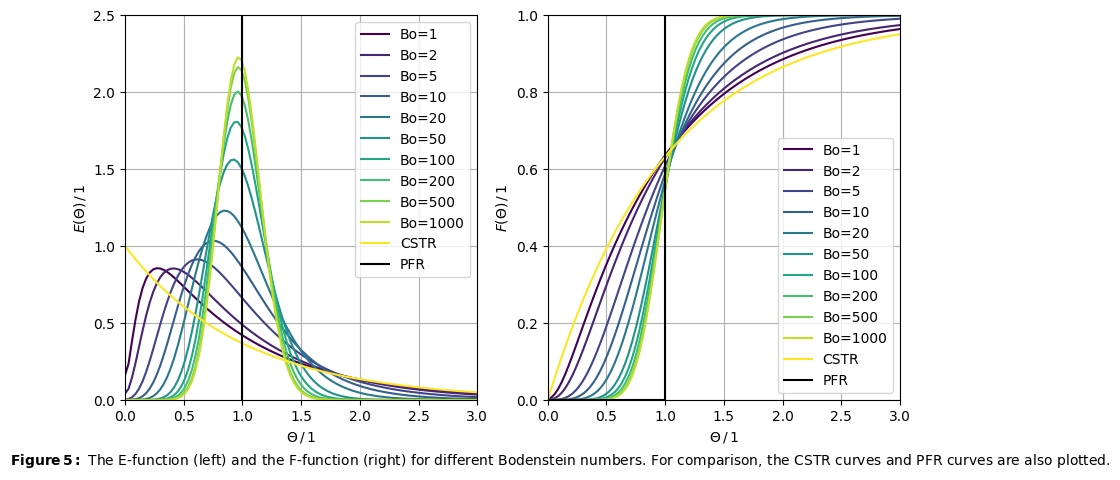

In [83]:
# plotting
colors = cmap(np.linspace(0,1,len(Bo)+1))
fig, ax = plt.subplots(1,2, figsize=(10,5))
for b in range(len(Bo)):
    ax[0].plot(theta_Disp[b], E_theta_Disp[b], color=colors[b], label=f"Bo={Bo[b]}")
ax[0].plot(theta_CSTR, E_theta_CSTR, color=colors[-1], label="CSTR")
ax[0].plot([1,1],[0,2.5], color="black", label="PFR")
ax[0].grid()
ax[0].set_xlim(0,3)
ax[0].set_ylim(0,2.5)
ax[0].set_xlabel(r"$\Theta\,/\,1$")
ax[0].set_ylabel(r"$E(\Theta)\,/\,1$")
ax[0].legend()
for b in range(len(Bo)):
    ax[1].plot(theta_Disp[b], F_theta_Disp[b], color=colors[b], label=f"Bo={Bo[b]}")
ax[1].plot(theta_CSTR, F_theta_CSTR, color=colors[-1], label="CSTR")
ax[1].plot([0,1,1,3],[0,0,1,1], color="black", label="PFR")
ax[1].grid()
ax[1].set_xlim(0,3)
ax[1].set_ylim(0,1)
ax[1].set_xlabel(r"$\Theta\,/\,1$")
ax[1].set_ylabel(r"$F(\Theta)\,/\,1$")
ax[1].legend()
fig.text(
    0.01, -0.02,
    "$\\mathbf{Figure\\,5:}$ The E-function (left) and the F-function (right) for different Bodenstein numbers. For comparison, the CSTR curves and PFR curves are also plotted.",
    ha='left',
    fontsize=10
)
plt.show()

The results show that at low $Bo$, the $E$- and $F$-profiles closely resemble those of a single CSTR, exhibiting a broad decay in $E(\theta)$ and a gradual rise in $F(\theta)$, which reflects strong backmixing characteristics of perfectly mixed flows. As $Bo$ increases, the peak of the $E$-function sharpens and shifts toward $\theta = 1$, while the tail shortens, indicating reduced dispersion and a narrower residence time distribution. At very high $Bo$, the distribution approaches that of a plug flow, as expected, with the $E$-function resembling a Dirac function centered at $\theta = 1$ and the $F$-function resembling a steep step. These observations confirm that increasing $Bo$ effectively suppresses axial dispersion and drives the system toward ideal plug-flow behavior.


### 4.4 Variation of $N_\mathrm{CSTR}$
Next, the influence of the number of CSTRs in series on the residence time distribuions is investigated and compared with the dispersion model. For this, the model was implemented as a cascade of perfectly mixed tanks and solved for different values of $N_\text{CSTR}$. The code computes the residence time distribution ($E$-function) and cumulative distribution ($F$-function) for each case and overlays the results for comparison.

In [43]:
c_T_in = 1  # inlet tracer concentration in mol m⁻³
V_dot = 1   # volumetric flow rate in m³ s⁻¹
V_R = 1     # reactor volume of a single CSTR in m³
N_CSTR = np.array([1,2,5,10,20,50,100]) # number of CSTRs in the Cascade


F_t_Cascade = {}
dtau = {}
E_t_Cascade = {}
theta_Cascade = {}
E_theta_Cascade = {}
F_theta_Cascade = {}
for NN in range(len(N_CSTR)):
    tau_mean_vessel = V_R/V_dot                 # mean residence time of a single vessel in s
    tau_mean_cascade = N_CSTR[NN]*tau_mean_vessel   # mean residence time of the cascade

    def CSTR_cascade_balance_dynamic(t, c):
        """
        Calculates the dynamic balance of a CSTR cascade without a reaction.

        :param t: Time at which the dynamic balance is to be calculated in s.
        :type t: float
        :param c: concentration of the tracer in mol m⁻³.
        :type c: np.ndarray
        :return: concentration gradient of the tracer in each vessel.
        :rtype: np.ndarray
        """
        dcdt_i = np.zeros_like(c)                       # initialize empty results array
        for i in range(N_CSTR[NN]):                         # iterate over each vessel
            if i == 0:                                  # special case for first vessel: takes the inlet concentration of the cascade
                dcdt_i[i] = V_dot/V_R * (c_T_in-c[i])   # balance eqaution of the first vessel
            else:
                dcdt_i[i] = V_dot/V_R * (c[i-1]-c[i])   # balance equation of vessel i according to equation (___)
        return dcdt_i

    theta_span = np.array([0,3])                        # dimensionless timespan which is evaluated
    c_T_a_0 = 0                                         # initial tracer composition
    init = np.ones(N_CSTR[NN])*c_T_a_0                      # initial concentration array
    t_span = theta_span*tau_mean_cascade                # timespan which is evaluated
    t_eval = np.linspace(t_span[0], t_span[1], 1001)    # discretization of the timepsan
    sol_Cascade = scipy.integrate.solve_ivp(CSTR_cascade_balance_dynamic, t_span, init, t_eval=t_eval, atol=1e-6, rtol=1e-6)    # solving the cascade IVP

    # calculate F(t) and E(t)
    F_t_Cascade[NN] = sol_Cascade.y[-1]/c_T_in          # F-function of the cascade
    dtau[NN] = np.gradient(sol_Cascade.t)               # differential timespan
    E_t_Cascade[NN] = np.gradient(F_t_Cascade[NN])/dtau[NN]     # E-function of the cascade in s⁻¹

    # calculate F(Theta) and E(Theta)
    theta_Cascade[NN] = sol_Cascade.t/tau_mean_cascade  # dimensionless timesteps
    E_theta_Cascade[NN] = tau_mean_cascade*E_t_Cascade[NN]  # dimensionless E-function of the cascade
    F_theta_Cascade[NN] = F_t_Cascade[NN]                   # dimensionless F-function of the cascade

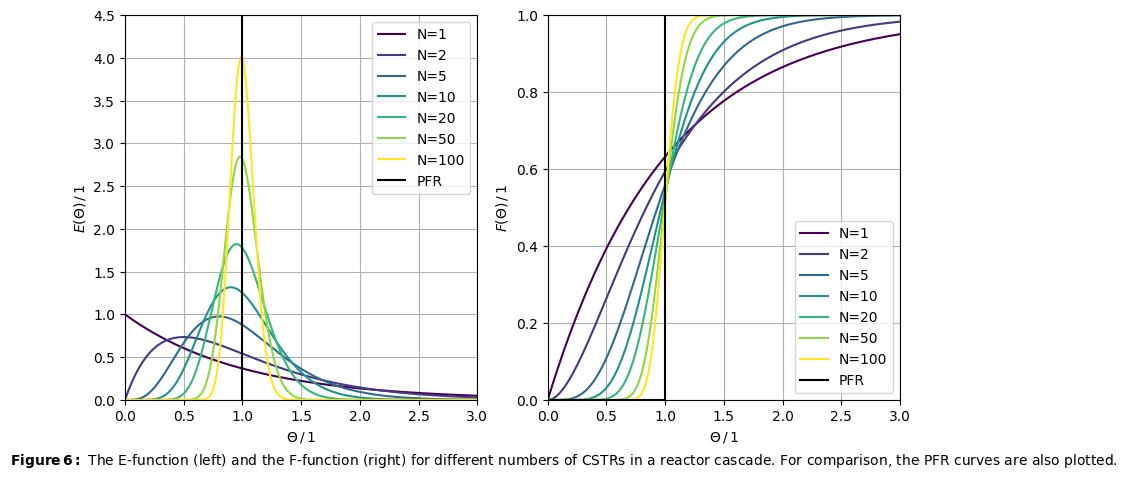

In [44]:
# plotting
colors = cmap(np.linspace(0,1,len(N_CSTR)))
fig, ax = plt.subplots(1,2, figsize=(10,5))
for NN in range(len(N_CSTR)):
    ax[0].plot(theta_Cascade[NN], E_theta_Cascade[NN], color=colors[NN], label=f"N={N_CSTR[NN]}")
ax[0].plot([1,1],[0,4.5], color="black", label="PFR")
ax[0].grid()
ax[0].set_xlim(0,3)
ax[0].set_ylim(0,4.5)
ax[0].set_xlabel(r"$\Theta\,/\,1$")
ax[0].set_ylabel(r"$E(\Theta)\,/\,1$")
ax[0].legend()
for NN in range(len(N_CSTR)):
    ax[1].plot(theta_Cascade[NN], F_theta_Cascade[NN], color=colors[NN], label=f"N={N_CSTR[NN]}")
ax[1].plot([0,1,1,3],[0,0,1,1], color="black", label="PFR")
ax[1].grid()
ax[1].set_xlim(0,3)
ax[1].set_ylim(0,1)
ax[1].set_xlabel(r"$\Theta\,/\,1$")
ax[1].set_ylabel(r"$F(\Theta)\,/\,1$")
ax[1].legend()
fig.text(
    0.01, -0.02,
    "$\\mathbf{Figure\\,6:}$ The E-function (left) and the F-function (right) for different numbers of CSTRs in a reactor cascade. For comparison, the PFR curves are also plotted.",
    ha='left',
    fontsize=10
)
plt.show()

The results show that for small $N_\text{CSTR}$ the distribution is very broad, indicating strong backmixing and a wide spread of residence times, similar to a CSTR. As $N_\text{CSTR}$ increases, the RTD curve becomes narrower and approaches the behavior of a plug flow, with a peak near $\theta = 1$. The $E$-function of the cascade model shows close similarity to the dispersion model at high $N_\text{CSTR}$, confirming that increasing the number of tanks reduces axial dispersion and backmixing. At intermediate $N_\text{CSTR}$, the distribution still shows some skewness, reflecting incomplete plug-flow behavior. These results illustrate how the number of CSTRs can be tuned to approximate different flow regimes and validate the use of the cascade model as a practical approximation of dispersive flow.

## 5. Conclusion

* Dispersion model was implemented and validated using the plug flow model
* Conversion dependent on backmixing, higher conversion for higher Bo
* Influence of backmixing stronger for higher reaction orders, e.g. 2
* Close to plug flow behavior for high Bodenstein numbers
* Cascade model as alternative to the dispersion model, a high number of vessels also machtes plug flow behavior, while one vessel equals CSTR behavior

## 6. References

[1] Dr.-Ing. Jens Friedland, CRE_3_assignment_4_25, Ulm, (2025). [LINK](https://moodle.uni-ulm.de/mod/assign/view.php?id=879171).

[2] Prof. Dr.-Ing. R. Güttel, T. Turek, Chemische Reaktionstechnik, Springer Berlin Heidelberg, Berlin, Heidelberg, (2021). [DOI](https://doi.org/10.1007/978-3-662-63150-8).

[3] Prof. Dr.-Ing. Robert Güttel, Lecture: "Chemische Verfahrenstechnik I", Ulm, (2025). [LINK](https://moodle.uni-ulm.de/mod/folder/view.php?id=807450).

## 7. Contribution

All group members equally contributed to the report.